# Spoken Wiki attentional word recognition pilot task results

In [60]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



In [61]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/')
# !ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("cocktail_party_cue_duration_pilot/data/*.json"))

# import vocab dict for matching audio & responses 
# word_and_speaker_encodings = pickle.load( open("/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
# # ix_to_word_map = {v:k for k,v in class_map.items()}
# class_map = word_and_speaker_encodings['word_idx_to_word']
len(human_fnames)

116

In [62]:
## Get all subject data into one df for analysis

def get_part_df(fname):
    part_data = json.load(open(fname, 'r'))
    # print(f"{fname.stem} success {part_data[0]['success']}")
    part_df = pd.DataFrame.from_records(part_data)
    ## Forward fill stim presentation entry to word response entry
    responses = part_df.loc[part_df.trial_type.isin(['audio-keyboard-response','dictionary-text']), ['trial_index', 'stimulus']]
    responses = responses.ffill()
    part_df.loc[part_df['trial_index'].isin(responses["trial_index"].values), 'stimulus'] = responses.stimulus
    return part_df

dfs = []
for fname in human_fnames:
    try:
        dfs.append(get_part_df(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)

## Filter for those who passed headphone check 

results_df = results_df[results_df.hc_passed == True]


## Add snr and condition names as columns - unpack from file code in file names 

import re
# get cond name map
map_path = Path('/om2/user/imgriff/projects/torch_2_aud_attn/human_pilot_cue_duration_cond_map.pkl')
with open(map_path, 'rb') as handle:
    stim_cond_map = pickle.load(handle)

stim_cond_map = {f"condition_{k}": v for k,v in stim_cond_map.items()}

## Map wav str to stim_type using condition dict
def get_stim_snr_and_cond(stim_str, stim_cond_map=stim_cond_map):
    condition, cue_dur = None,  None 
    if isinstance(stim_str, str) and not stim_str.startswith('<'):
        cond_str = re.search("condition_(-?\d+)", stim_str)
        if cond_str:
            cond_str = cond_str.group(0)
            cue_dur = stim_cond_map[cond_str]
            condition = 'trial'
        elif 'catch' in stim_str:
            condition = 'catch_trial'
            cue_dur = 2
    return cue_dur, condition

# add as columns 
results_df['cue_dur'], results_df['condition'] = zip(*results_df['stimulus'].apply(get_stim_snr_and_cond))

# cut down df to only have trial answers (remove other meta data)
expmnt_trial_str = "dictionary-text"
trial_results = results_df[results_df.trial_type == expmnt_trial_str]

# Convert condition names to  readable format 
# test_condition_dict = {'music':"background_musdb18hq",
#                        "babble":"background_cv08talkerbabble",
#                        "stationary": "background_issnstationary",
#                        "modulated": "background_issnfestenplomp",
#                        "audioset": "background_audioset",
#                        "natural scene": "background_ieeeaaspcasa",
#                        "clean": "SILENCE"}

# condition_map = {v:k for k,v in test_condition_dict.items()}
# trial_results['condition'] = trial_results['condition'].replace(condition_map)

trial_results = trial_results[trial_results.id_version == 1]

# screen based on completion 
total_trials = 95
full_run_subjects = [subj_id for subj_id, did_all_trials in (trial_results.groupby('id_subject').condition.count() == total_trials).items() if did_all_trials == True]
trial_results = trial_results[trial_results.id_subject.isin(full_run_subjects)]

# Add accuracy 
trial_results['accuracy'] = (trial_results['response_str'] == trial_results['correct_response']).astype('int')


Unterminated string starting at: line 1 column 83828 (char 83827)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_cue_duration_pilot/data/subj_6432eb0312d98a4e9d92712a.json
Expecting ':' delimiter: line 1 column 83855 (char 83854)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_cue_duration_pilot/data/subj_614f3ad3e0837475bb79d175.json
Unterminated string starting at: line 1 column 71919 (char 71918)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_cue_duration_pilot/data/subj_6160717242827a64a55d99ad.json
Expecting ',' delimiter: line 1 column 83860 (char 83859)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_cue_duration_pilot/data/subj_65f5fd5026b268bf89ec3e1e.json
Unterminated string starting at: line 1 column 143820 (char 143819)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_cue_duration_pilot/data/subj_5fc10a4e1de4be09d6c3d2e7.json
Unterminated string starting at: line 1 column 131822 (char 131821)
/mindhive/mcdermott/www/imgriff/msjs

In [63]:
# ids_to_check = ['614f3ad3e0837475bb79d175', '63d842d3e9626bd5fe5c17b1', '5c4068a67f81e900012b281e', '64157c7105837695ad52b091']


In [64]:
# results_df[results_df.id_subject == '614f3ad3e0837475bb79d175']

In [65]:
# to_check = results_df[results_df.id_subject.isin(ids_to_check)]
# to_check[(~to_check.response_str.isna())].groupby('id_subject')['trial_type'].count()

In [66]:
# trial_results

In [67]:
# stim_cond_map

In [68]:
# results_df.id_subject.unique()

### Select participants based on catch trial performance

In [69]:
catch_trial_particiapnt_performance = trial_results[trial_results.condition == 'catch_trial'].groupby('id_subject').accuracy.mean()
# catch_trial_particiapnt_performance

In [70]:
print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 13/15].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]

N total participants  54
N good participants  42


In [71]:
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response_str.isna())]
# analysis_df.groupby('id_subject').condition.count()

In [72]:


### Look at 1 talker sex conditions

manifest = pd.read_pickle("/om/user/imgriff/datasets/human_cue_duration_SWC_2024/manifest_w_transcripts.pdpkl")
manifest["base_trial"] = manifest.mixture_fn.apply(lambda x: x.as_posix().split('/')[-1]) 

## Will add columns 'base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender' from manifest to trial_results where trial_results.stimulus == manifest.base_str
analysis_df['base_trial'] = analysis_df.stimulus.apply(lambda x: x.split('/')[-1])

# analysis_df = pd.merge(analysis_df,
#                         manifest[['base_trial', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender', 'distractor_word']],
#                                     left_on='base_trial', right_on='base_trial', how='left')
# analysis_df['confusions'] = (analysis_df.response_str == analysis_df.distractor_word).astype('int')


analysis_df = pd.merge(analysis_df,
                        manifest[['base_trial', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender', 'distractor_word', 'target_transcripts', 'distractor_transcripts']],
                                    left_on='base_trial', right_on='base_trial', how='left')
analysis_df['confusions'] = (analysis_df.response == analysis_df.distractor_word).astype('int')


# add adjusted accuracy and confusions 
target_words = analysis_df.response.values
target_transcripts = analysis_df.target_transcripts.values
distractor_transcripts = analysis_df.distractor_transcripts.values


adjusted_acc = np.array([int(target_word in target_transcript)
                            if not isinstance(target_transcript, float) else np.nan
                             for target_word, target_transcript in zip(target_words, target_transcripts)
                              ])

adjusted_confs = np.array([int(target_word in distractor_transcript)
                            if not isinstance(distractor_transcript, float) else np.nan
                             for target_word, distractor_transcript in zip(target_words, distractor_transcripts)
                              ])

analysis_df['adjusted_accuracy'] = adjusted_acc
analysis_df['adjusted_confusions'] = adjusted_confs



In [73]:
analysis_df['gender_cond'] = analysis_df['target_gender'].values == analysis_df['distractor_gender'].values
analysis_df['gender_cond'] = analysis_df['gender_cond'].replace({True: 'Same sex', False: 'Different sex'})

In [104]:
## Make a df of just the first half of the experiment
first_half = analysis_df[analysis_df.trial_index <= 47]

In [113]:
# get trial data excluding catch trials 


first_half_summary = (first_half[analysis_df['condition'] == 'trial'].groupby(['id_subject', "gender_cond", "cue_dur"])
                     .agg({'adjusted_accuracy':['mean', 'sem', 'count'], 'adjusted_confusions':['mean', 'sem', 'count']})
                     .reset_index())

# first_half_summary['snr'] = first_half_summary['snr'].replace(np.inf, 6)
# first_half_summary['snr'] =  first_half_summary['snr'].replace("inf", 6)
# first_half_summary['snr'] = first_half_summary['snr'].astype('int')
# flatten multiindex 
first_half_summary.columns = ['_'.join(col).strip() for col in first_half_summary.columns.values]
# remove trailing underscore
first_half_summary.columns = [col[:-1] if col.endswith('_') else col for col in first_half_summary.columns.values]


/tmp/ipykernel_1157466/314274203.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  first_half_summary = (first_half[analysis_df['condition'] == 'trial'].groupby(['id_subject', "gender_cond", "cue_dur"])


In [ ]:
analysis_df[analysis_df['condition'] == 'trial'].groupby(['id_subject', 'cue_dur']).value_counts()

### Group participant data for plotting and stats

In [74]:
# get trial data excluding catch trials 


part_summary_df = (analysis_df[analysis_df['condition'] == 'trial'].groupby(['id_subject', "gender_cond", "cue_dur"])
                     .agg({'adjusted_accuracy':['mean', 'sem', 'count'], 'adjusted_confusions':['mean', 'sem', 'count']})
                     .reset_index())

# part_summary_df['snr'] = part_summary_df['snr'].replace(np.inf, 6)
# part_summary_df['snr'] =  part_summary_df['snr'].replace("inf", 6)
# part_summary_df['snr'] = part_summary_df['snr'].astype('int')
# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]


### Get model results

In [75]:
## import class maps
import pickle
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}

### Get conditions 
path_to_expmt_stim = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2024/")
human_exp_word_key = pickle.load( open(path_to_expmt_stim / "human_attn_expmt_word_key.pkl", "rb" )) 
exp_word_2_class = {v:k for k,v in human_exp_word_key.items()}

manifests = pd.read_pickle(path_to_expmt_stim / "human_cue_target_distractor_df_w_meta_transcripts_w_f0.pdpkl")
manifests['word_fname_int'] = manifests['word'].replace(exp_word_2_class)
manifests['stim_name'] = manifests[['gender', 'word_fname_int']].apply(lambda row: f"{row.gender[0]}_{row.word_fname_int:03d}", axis=1)
cols_to_merge = [
                #  'stim_name',
                 'gender',
                 'word',
                 'word_int',
                 'target_f0',
                 'english_distractor_f0',
                 'mandarin_distractor_f0',
                 'dutch_distractor_f0',
                 'target_transcripts',
                 'same_sex_distractor_1_transcripts',
                 'diff_sex_distractor_1_transcripts',
                 "same_sex_dist_1_word",
                 "diff_sex_dist_1_word"

]
manifests['word_int'] = manifests.word.replace(cv_word_2_class)
model_manifest = manifests[cols_to_merge].sort_values(['gender', 'word']).copy()
model_manifest['df_index'] = model_manifest.index



In [76]:
## import class maps
import pickle
## load WSN vocab mapping 
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
wsn_word_2_class = word_and_speaker_encodings['word_to_idx']
wsn_class_2_word = word_and_speaker_encodings['word_idx_to_word']
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}



In [77]:
from src.util_analysis import model_name_dict
manifest = pd.read_pickle("/om/user/imgriff/datasets/human_cue_duration_SWC_2024/manifest_w_transcripts.pdpkl")


model_names = ['word_task_v10_main_feature_gain_config']


all_model_results = []
all_model_f0_results = []

# Convert condition names to  readable format 
test_condition_dict = {'music':"background_musdb18hq",
                    "babble":"background_cv08talkerbabble",
                    "stationary": "background_issnstationary",
                    "modulated": "background_issnfestenplomp",
                    "audioset": "background_audioset",
                    "natural scene": "background_ieeeaaspcasa",
                    "clean": "SILENCE"}
str_to_cond = {v:k for k,v in test_condition_dict.items()}

# update gt manifests to match readable format 
manifest["background_condition"] = manifest.condition.replace(str_to_cond, )

for model_name in model_names:
    if 'affine' not in model_name and 'no_cue' not in model_name:
        print(model_name)
        output_paths = list(Path(f'/om2/user/rphess/Auditory-Attention/cue_duration_eval/{model_name}').glob('*.csv'))
    else:
        output_paths = list(Path(f'cue_duration_eval/{model_name}').glob('*.csv'))
    if 'v1' in model_name:
        output_paths = list(Path(f'cue_duration_eval_center_crop/{model_name}').glob('*.csv'))


    print(len(output_paths))

    results_dfs = []

    for path in output_paths:
        if "v10" in path.stem and 'talker_' in path.stem:
            continue
        df = pd.read_csv(path)
        # reformat dict
        df['model'] = path.parent.name
        #parts of name 
        parts = path.stem.split(path.parent.name)[-1].split('_')       
        if "background" in path.stem:
            df['background_condition'] = str_to_cond['_'.join(parts[1:3])]
        else:
            df['background_condition'] = parts[1]
        if 'SILENCE' in path.stem:
            df['background_condition'] = 'clean'
            df['snr'] =  'inf' # really np.inf, 6 for plotting 
        else:
            df['snr'] = int(re.search('(-?\d+)dB', path.stem).group(0).strip('dB'))
        df['cue_dur'] = int(re.search('(-?\d+)ms', path.stem).group(0).strip('ms'))
        if "v10" in model_name:
            df['test_index'] = df.index
            df = pd.merge(df,
                model_manifest,
                            left_on=["test_index", "true_word_int"], right_on=["df_index", "word_int"])

        results_dfs.append(df)
    model_results = pd.concat(results_dfs, axis=0, ignore_index=True)
    model_str = model_name_dict[model_name] if model_name in model_name_dict else model_name
    model_results['group'] = model_str
    ## Load in model vocab 
    class_2_word =  wsn_class_2_word if 'WordSpeakerNoise' in model_str else  cv_class_2_word
    model_results['pred_word'] = model_results['pred_word_int'].replace(class_2_word)
    model_results['true_word'] = model_results['true_word_int'].replace(class_2_word)


    # # Add 1-talker condition metadata to model results

    pred_words = model_results.pred_word.values
    target_words = model_results.word.values
    target_transcripts = model_results.target_transcripts.values
    same_sex_distractor_words = model_results.same_sex_dist_1_word.values
    diff_sex_distractor_words = model_results.same_sex_dist_1_word.values
    same_sex_distractor_transcripts = model_results.same_sex_distractor_1_transcripts.values
    diff_sex_distractor_transcripts = model_results.diff_sex_distractor_1_transcripts.values


    adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                                if not isinstance(target_transcript, float) else np.nan
                                for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                                ])

    adjusted_confs = np.array([int(pred_word in same_sex_transcript or pred_word in diff_sex_transcript or pred_word == same_sex_word or pred_word == diff_sex_word)
                                if not (isinstance(same_sex_transcript, float) and isinstance(diff_sex_transcript, float)) else np.nan
                                for pred_word, same_sex_word, diff_sex_word, same_sex_transcript, diff_sex_transcript in zip(pred_words, same_sex_distractor_words, diff_sex_distractor_words,  same_sex_distractor_transcripts, diff_sex_distractor_transcripts)
                                ])

    
    
    model_results['adjusted_accuracy'] = adjusted_acc
    model_results['adjusted_confusions'] = adjusted_confs
    
    all_model_results.append(model_results)



all_model_results = pd.concat(all_model_results, axis=0, ignore_index=True)
# all_model_f0_results = pd.concat(all_model_f0_results, axis=0, ignore_index=True)


# all_model_results['gender_cond'] = all_model_results.apply(lambda row: 'Same sex' if row['target_gender'] == row['distractor_gender'] else 'Different sex', axis=1)

all_model_results['cue_dur'] = all_model_results['cue_dur'] / 1000

word_task_v10_main_feature_gain_config
8


In [78]:
all_model_results['gender_cond'] = all_model_results.background_condition.apply(lambda row: 'Same sex' if 'same' in row else 'Different sex')


### Combine model and participant results

In [114]:
part_summary_df['group'] = f"Participants (N={part_summary_df.id_subject.nunique()})"
part_summary_df.rename(columns={'adjusted_accuracy_mean': 'adjusted_accuracy', 'adjusted_confusions_mean': "adjusted_confusions"}, inplace=True)

all_model_results['group'] = all_model_results['group']
all_results = pd.concat([part_summary_df, all_model_results], axis=0, ignore_index=True)


# combine with only first half of experiment

first_half_summary['group'] = f"Participants (N={first_half_summary.id_subject.nunique()})"
first_half_summary.rename(columns={'adjusted_accuracy_mean': 'adjusted_accuracy', 'adjusted_confusions_mean': "adjusted_confusions"}, inplace=True)
first_half_w_model = pd.concat([first_half_summary, all_model_results], axis=0, ignore_index=True)

In [109]:
# all_model_results[all_model_results.cue_dur == 2000].accuracy.mean()

In [110]:
all_results.groupby(['group',
                     'cue_dur']).adjusted_accuracy.mean()

group                cue_dur
Feature-gain v10     0.25       0.396004
                     0.50       0.471311
                     1.00       0.503586
                     2.00       0.524078
Participants (N=42)  0.25       0.495071
                     0.50       0.568660
                     1.00       0.615142
                     2.00       0.622172
Name: adjusted_accuracy, dtype: float64

In [115]:
first_half_w_model.groupby(['group',
                     'cue_dur']).adjusted_accuracy.mean()

group                cue_dur
Feature-gain v10     0.25       0.396004
                     0.50       0.471311
                     1.00       0.503586
                     2.00       0.524078
Participants (N=42)  0.25       0.393056
                     0.50       0.474138
                     1.00       0.485380
                     2.00       0.410053
Name: adjusted_accuracy, dtype: float64

## Standard analysis plots

Text(0.5, 1.05, 'Using 1 disractor at 0 dB SNR')

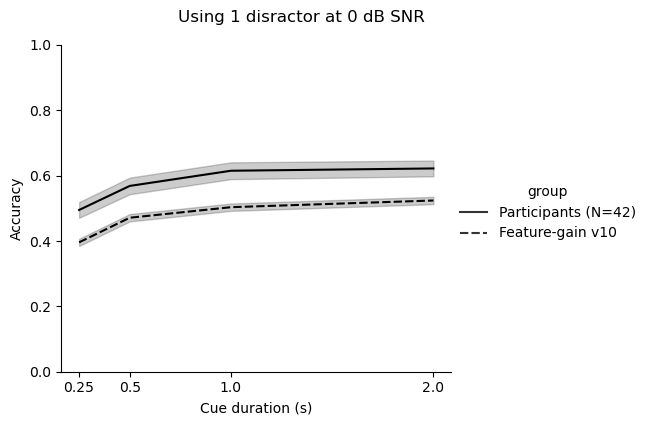

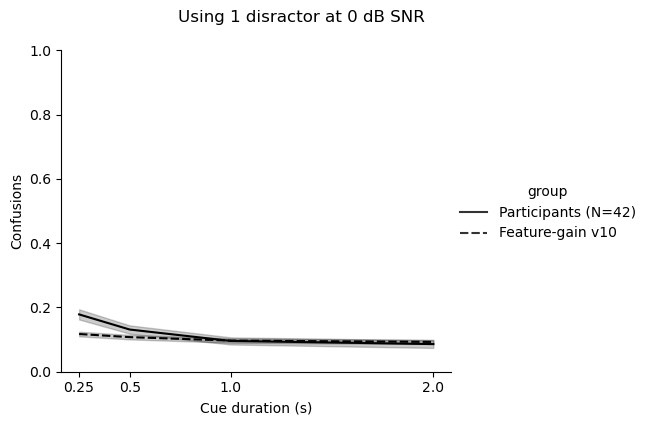

In [84]:
to_plot = all_results[all_results.cue_dur.isin([0.25, 0.5,1,2])]


#group_order = [ f"Participants (N={part_summary_df.id_subject.nunique()})", 'Model']
# add markers to relplot
g = sns.relplot(data=to_plot, x='cue_dur', y='adjusted_accuracy', # hue='gender_cond',
                # col_wrap=3,
                style='group',# style_order=group_order,
                
                kind='line', marker='',
                color='k',
                height=4, aspect=1.25,
                # err_style='bars', 
                errorbar=('se', 1),)

# set labels 
g.set_axis_labels("Cue duration (s)", "Accuracy")
g.set_titles("{col_name}")

# add xtick labels 
g.ax.set_xticks(ticks=to_plot.cue_dur.unique())
g.set_xticklabels(to_plot.cue_dur.unique())

plt.ylim(0,1)
plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)

# add markers to relplot
g = sns.relplot(data=to_plot, x='cue_dur', y='adjusted_confusions', # hue='gender_cond',
                # col_wrap=3,
                style='group', #style_order=group_order,
                
                kind='line', marker='',
                color='k',
                height=4, aspect=1.25,
                # err_style='bars', 
                errorbar=('se', 1),)


# set labels 
g.set_axis_labels("Cue duration (s)", "Confusions")
g.set_titles("{col_name}")

# add xtick labels 
g.ax.set_xticks(ticks=to_plot.cue_dur.unique())
g.set_xticklabels(to_plot.cue_dur.unique())

plt.ylim(0,1)
plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)
# plt.tight_layout()

Text(0.5, 1.05, 'Using 1 disractor at 0 dB SNR')

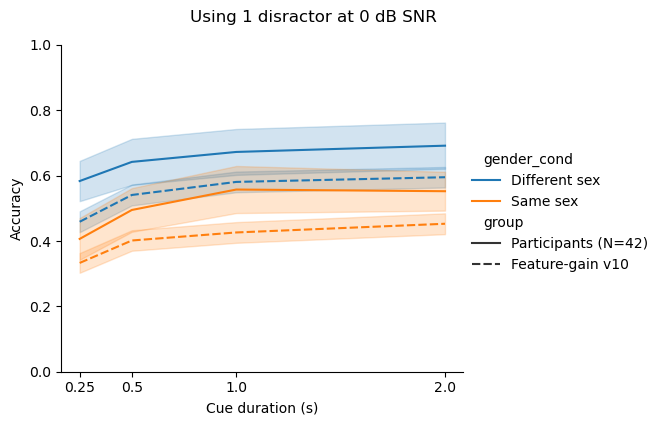

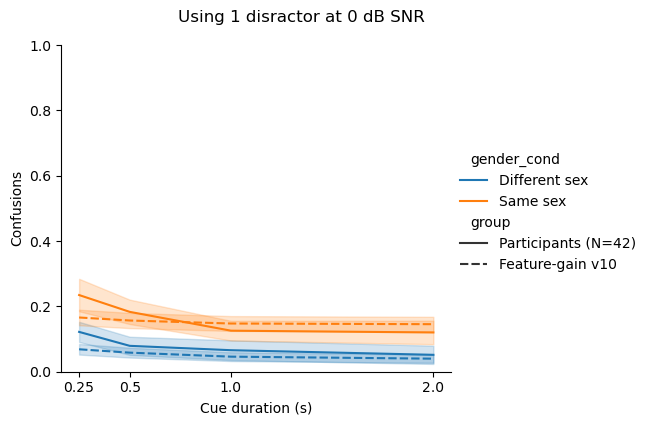

In [85]:
to_plot = all_results[all_results.cue_dur.isin([0.25, 0.5,1,2])]


group_order = [ f"Participants (N={part_summary_df.id_subject.nunique()})", 'Model']
# add markers to relplot
g = sns.relplot(data=to_plot, x='cue_dur', y='adjusted_accuracy',  hue='gender_cond',
                # col_wrap=3,
                style='group',# style_order=group_order,
                
                kind='line', marker='',
                # color='k',
                height=4, aspect=1.25,
                # err_style='bars',
                 errorbar=('se', 2),)

# set labels 
g.set_axis_labels("Cue duration (s)", "Accuracy")
g.set_titles("{col_name}")

# add xtick labels 
g.ax.set_xticks(ticks=to_plot.cue_dur.unique())
g.set_xticklabels(to_plot.cue_dur.unique())

plt.ylim(0,1)
plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)

# add markers to relplot
g = sns.relplot(data=to_plot, x='cue_dur', y='adjusted_confusions',  hue='gender_cond',
                # col_wrap=3,
                style='group',# style_order=group_order,
                
                kind='line', marker='',
                color='k',
                height=4, aspect=1.25,
                # err_style='bars', 
                errorbar=('se', 2),)


# set labels 
g.set_axis_labels("Cue duration (s)", "Confusions")
g.set_titles("{col_name}")

# add xtick labels 
g.ax.set_xticks(ticks=to_plot.cue_dur.unique())
g.set_xticklabels(to_plot.cue_dur.unique())

plt.ylim(0,1)
plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)
# plt.tight_layout()

In [86]:
to_plot

,id_subject,gender_cond,cue_dur,adjusted_accuracy,adjusted_accuracy_sem,adjusted_accuracy_count,adjusted_confusions,adjusted_confusions_sem,adjusted_confusions_count,group,...,mandarin_distractor_f0,dutch_distractor_f0,target_transcripts,same_sex_distractor_1_transcripts,diff_sex_distractor_1_transcripts,same_sex_dist_1_word,diff_sex_dist_1_word,df_index,pred_word,true_word
0,542bdb6dfdf99b324ea37c3a,Different sex,0.25,0.727273,0.140836,11.0,0.090909,0.090909,11.0,Participants (N=42),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,542bdb6dfdf99b324ea37c3a,Different sex,0.50,0.600000,0.163299,10.0,0.000000,0.000000,10.0,Participants (N=42),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,542bdb6dfdf99b324ea37c3a,Different sex,1.00,0.777778,0.146986,9.0,0.000000,0.000000,9.0,Participants (N=42),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,542bdb6dfdf99b324ea37c3a,Different sex,2.00,0.833333,0.112367,12.0,0.000000,0.000000,12.0,Participants (N=42),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,542bdb6dfdf99b324ea37c3a,Same sex,0.25,0.333333,0.166667,9.0,0.444444,0.175682,9.0,Participants (N=42),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8139,NaN,Same sex,0.50,0.000000,NaN,NaN,0.000000,NaN,NaN,Feature-gain v10,...,151.157425,161.634552,"[and, originally, wrote, baba, oriordan]","[of, division, between, renton, and, wood]","[the, book, reached, number, one, on, the, boo...",between,reached,971.0,route,wrote
8140,NaN,Same sex,0.50,1.000000,NaN,NaN,0.000000,NaN,NaN,Feature-gain v10,...,123.922554,141.201233,"[or, gingemid, a, yellow, green, light, pair]","[use, markov, state, models, for, an]","[the, sillagorn, state, government]",state,state,972.0,yellow,yellow
8141,NaN,Same sex,0.50,1.000000,NaN,NaN,0.000000,NaN,NaN,Feature-gain v10,...,187.242538,248.804810,"[and, grayish, yellow, legs]","[and, central, africa, football, association]","[only, led, the, club, to, three, consecutive,...",africa,three,973.0,yellow,yellow
8142,NaN,Same sex,0.50,0.000000,NaN,NaN,1.000000,NaN,NaN,Feature-gain v10,...,221.811417,175.334808,"[parents, care, for, the, young, for, a, time]","[compounds, and, heavy, metals]","[nobody, else, could, do]",heavy,could,974.0,heavy,young


In [87]:
all_results.group.unique()

array(['Participants (N=42)', 'Feature-gain v10 '], dtype=object)

In [143]:

### Compute accuracy delta

for (model, cue_dur, gender_cond), df in all_results.groupby(['group', 'cue_dur', 'gender_cond']):
    # get mean in condition for 2 second cue 
    baseline = all_results[(all_results.group == model) & (all_results.cue_dur == 2) & (all_results.gender_cond == gender_cond)].adjusted_accuracy.mean()
    baseline_confusions = all_results[(all_results.group == model) & (all_results.cue_dur == 2) & (all_results.gender_cond == gender_cond)].adjusted_confusions.mean()
    ix_for_cond = (all_results.group == model) & (all_results.cue_dur == cue_dur) & (all_results.gender_cond == gender_cond) 
    all_results.loc[ix_for_cond, 'accuracy_delta'] = all_results.loc[ix_for_cond, 'adjusted_accuracy'] - baseline 
    all_results.loc[ix_for_cond, 'confusions_delta'] = all_results.loc[ix_for_cond, 'adjusted_confusions'] - baseline_confusions 



In [116]:
### Compute accuracy delta

for (model, cue_dur, gender_cond), df in first_half_w_model.groupby(['group', 'cue_dur', 'gender_cond']):
    # get mean in condition for 2 second cue 
    baseline = first_half_w_model[(first_half_w_model.group == model) & (first_half_w_model.cue_dur == 2) & (first_half_w_model.gender_cond == gender_cond)].adjusted_accuracy.mean()
    baseline_confusions = first_half_w_model[(first_half_w_model.group == model) & (first_half_w_model.cue_dur == 2) & (first_half_w_model.gender_cond == gender_cond)].adjusted_confusions.mean()
    ix_for_cond = (first_half_w_model.group == model) & (first_half_w_model.cue_dur == cue_dur) & (first_half_w_model.gender_cond == gender_cond) 
    first_half_w_model.loc[ix_for_cond, 'accuracy_delta'] = first_half_w_model.loc[ix_for_cond, 'adjusted_accuracy'] - baseline 
    first_half_w_model.loc[ix_for_cond, 'confusions_delta'] = first_half_w_model.loc[ix_for_cond, 'adjusted_confusions'] - baseline_confusions 

### Make plot comparing first vs full experiment 



/tmp/ipykernel_1157466/2767651100.py:25: MatplotlibDeprecationWarning: 
The is_first_row function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_row() instead.
  if ax.is_first_row():
/tmp/ipykernel_1157466/2767651100.py:27: MatplotlibDeprecationWarning: 
The is_last_row function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_last_row() instead.
  if ax.is_last_row():
/tmp/ipykernel_1157466/2767651100.py:29: MatplotlibDeprecationWarning: 
The is_last_row function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_last_row() instead.
  if not (ax.is_last_row() and ax.is_first_col()):
/tmp/ipykernel_1157466/2767651100.py:29: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  

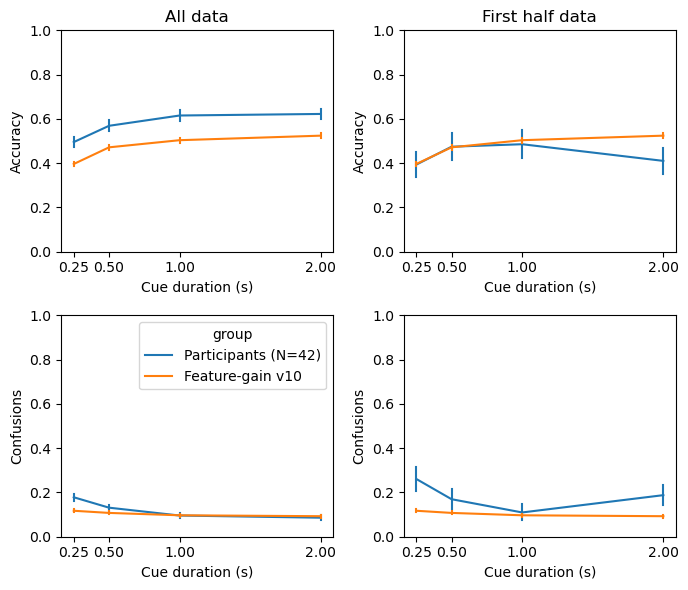

In [160]:
fig, axs = plt.subplots(2,2, figsize=(7, 6))
all_to_plot = all_results[(all_results.cue_dur.isin([0.25, 0.5,1,2])) & (all_results.group.isin(group_order))].copy()
first_h_to_plot = first_half_w_model[(first_half_w_model.cue_dur.isin([0.25, 0.5,1,2])) & (first_half_w_model.group.isin(group_order))].copy()

for ix, data_split in enumerate([all_to_plot, first_h_to_plot]):
    sns.lineplot(data=data_split, x='cue_dur', y='adjusted_accuracy',
                hue='group',
                marker='',
                color='k',
                err_style='bars', 
                errorbar=('se', 1),
                ax=axs[0, ix])
    sns.lineplot(data=data_split, x='cue_dur', y='adjusted_confusions',
                hue='group',
                  marker='',
                color='k',
                err_style='bars', 
                errorbar=('se', 1),
                ax=axs[1, ix])
    
for ax in axs.flatten():
    ax.set_ylim(0,1)
    ax.set_xticks(data_split.cue_dur.unique())
    ax.set_xlabel('Cue duration (s)')
    if ax.is_first_row():
        ax.set_ylabel('Accuracy')
    if ax.is_last_row():
        ax.set_ylabel('Confusions')
    if not (ax.is_last_row() and ax.is_first_col()):
        ax.get_legend().remove()

axs[0, 0].set_title('All data')
axs[0, 1].set_title('First half data')
plt.tight_layout()

In [147]:
to_plot

,id_subject,gender_cond,cue_dur,adjusted_accuracy,adjusted_accuracy_sem,adjusted_accuracy_count,adjusted_confusions,adjusted_confusions_sem,adjusted_confusions_count,group,...,target_transcripts,same_sex_distractor_1_transcripts,diff_sex_distractor_1_transcripts,same_sex_dist_1_word,diff_sex_dist_1_word,df_index,pred_word,true_word,accuracy_delta,confusions_delta
0,542bdb6dfdf99b324ea37c3a,Different sex,0.25,0.727273,0.140836,11.0,0.090909,0.090909,11.0,Participants (N=42),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.035417,0.039184
1,542bdb6dfdf99b324ea37c3a,Different sex,0.50,0.600000,0.163299,10.0,0.000000,0.000000,10.0,Participants (N=42),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.091855,-0.051726
2,542bdb6dfdf99b324ea37c3a,Different sex,1.00,0.777778,0.146986,9.0,0.000000,0.000000,9.0,Participants (N=42),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.085922,-0.051726
3,542bdb6dfdf99b324ea37c3a,Different sex,2.00,0.833333,0.112367,12.0,0.000000,0.000000,12.0,Participants (N=42),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.141478,-0.051726
4,542bdb6dfdf99b324ea37c3a,Same sex,0.25,0.333333,0.166667,9.0,0.444444,0.175682,9.0,Participants (N=42),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.219156,0.324278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8139,NaN,Same sex,0.50,0.000000,NaN,NaN,0.000000,NaN,NaN,Feature-gain v10,...,"[and, originally, wrote, baba, oriordan]","[of, division, between, renton, and, wood]","[the, book, reached, number, one, on, the, boo...",between,reached,971.0,route,wrote,-0.452869,-0.145492
8140,NaN,Same sex,0.50,1.000000,NaN,NaN,0.000000,NaN,NaN,Feature-gain v10,...,"[or, gingemid, a, yellow, green, light, pair]","[use, markov, state, models, for, an]","[the, sillagorn, state, government]",state,state,972.0,yellow,yellow,0.547131,-0.145492
8141,NaN,Same sex,0.50,1.000000,NaN,NaN,0.000000,NaN,NaN,Feature-gain v10,...,"[and, grayish, yellow, legs]","[and, central, africa, football, association]","[only, led, the, club, to, three, consecutive,...",africa,three,973.0,yellow,yellow,0.547131,-0.145492
8142,NaN,Same sex,0.50,0.000000,NaN,NaN,1.000000,NaN,NaN,Feature-gain v10,...,"[parents, care, for, the, young, for, a, time]","[compounds, and, heavy, metals]","[nobody, else, could, do]",heavy,could,974.0,heavy,young,-0.452869,0.854508


/tmp/ipykernel_1157466/1274652920.py:43: MatplotlibDeprecationWarning: 
The is_last_row function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_last_row() instead.
  if not (ax.is_last_row() and ax.is_first_col()):
/tmp/ipykernel_1157466/1274652920.py:45: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():
/tmp/ipykernel_1157466/1274652920.py:47: MatplotlibDeprecationWarning: 
The is_last_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_last_col() instead.
  if ax.is_last_col():
/tmp/ipykernel_1157466/1274652920.py:43: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  

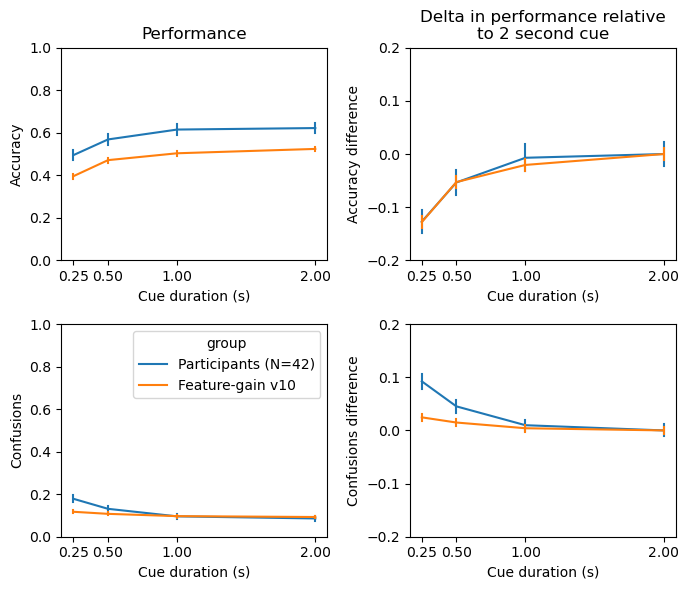

In [164]:
fig, axs = plt.subplots(2,2, figsize=(7, 6))
to_plot = all_results[(all_results.cue_dur.isin([0.25, 0.5,1,2])) & (all_results.group.isin(group_order))].copy()

sns.lineplot(data=to_plot, x='cue_dur', y='adjusted_accuracy',
            hue='group',
            marker='',
            color='k',
            err_style='bars', 
            errorbar=('se', 1),
            ax=axs[0, 0])
axs[0, 0].set_ylabel('Accuracy')

sns.lineplot(data=to_plot, x='cue_dur', y='accuracy_delta',
            hue='group',
            marker='',
            color='k',
            err_style='bars', 
            errorbar=('se', 1),
            ax=axs[0, 1])
axs[0, 1].set_ylabel('Accuracy difference')

sns.lineplot(data=to_plot, x='cue_dur', y='adjusted_confusions',
            hue='group',
                marker='',
            color='k',
            err_style='bars', 
            errorbar=('se', 1),
            ax=axs[1, 0])
axs[1, 0].set_ylabel('Confusions')

sns.lineplot(data=to_plot, x='cue_dur', y='confusions_delta',
            hue='group',
                marker='',
            color='k',
            err_style='bars', 
            errorbar=('se', 1),
            ax=axs[1, 1])
axs[1, 1].set_ylabel('Confusions difference')

for ax in axs.flatten():
    ax.set_xticks(data_split.cue_dur.unique())
    ax.set_xlabel('Cue duration (s)')
    if not (ax.is_last_row() and ax.is_first_col()):
        ax.get_legend().remove()
    if ax.is_first_col():
        ax.set_ylim(0,1)
    if ax.is_last_col():
        ax.set_ylim(-0.2, 0.2)

axs[0, 0].set_title('Performance')
axs[0, 1].set_title('Delta in performance relative\nto 2 second cue')
plt.tight_layout()

Text(0.5, 1.05, 'Using 1 disractor at 0 dB SNR')

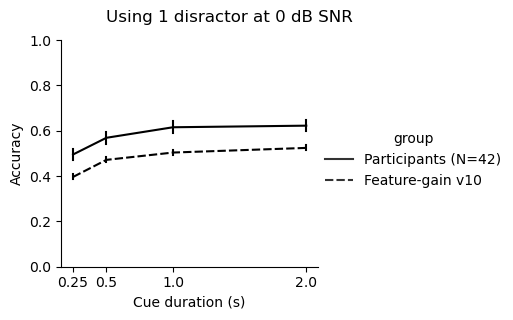

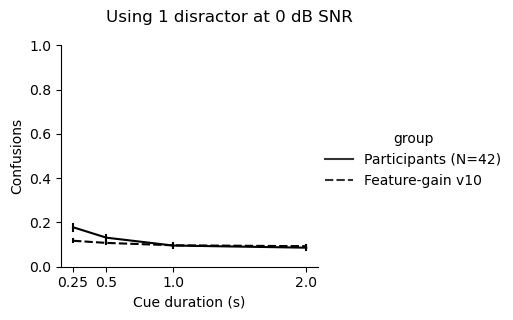

In [102]:
### new model vs humans 



group_order = [ f"Participants (N={part_summary_df.id_subject.nunique()})", 'Feature-gain v10 ']
to_plot = all_results[(all_results.cue_dur.isin([0.1, 0.25, 0.5,1,2])) & (all_results.group.isin(group_order))].copy()
# add markers to relplot
g = sns.relplot(data=to_plot, x='cue_dur', y='adjusted_accuracy', # hue='gender_cond',
                # col_wrap=3,
                # col='group', col_order=group_order,
                style='group',
                kind='line', marker='',
                color='k',
                height=3, aspect=1.25,
                err_style='bars', 
                errorbar=('se', 1),)

# set labels 
g.set_axis_labels("Cue duration (s)", "Accuracy")
g.set_titles("{col_name}")

# add xtick labels
for ax in g.axes.flatten():
    ax.set_xticks(ticks=to_plot.cue_dur.unique())
    ax.set_xticklabels(to_plot.cue_dur.unique())

plt.ylim(0,1)
plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)

# add markers to relplot
g = sns.relplot(data=to_plot, x='cue_dur', y='adjusted_confusions', # hue='gender_cond',
                # col='group', col_order=group_order,
                style='group',
                kind='line', marker='',
                color='k',
                height=3, aspect=1.25,
                err_style='bars', 
                errorbar=('se', 1),)


# set labels 
g.set_axis_labels("Cue duration (s)", "Confusions")
g.set_titles("{col_name}")

# add xtick labels 

# add xtick labels
for ax in g.axes.flatten():
    ax.set_xticks(ticks=to_plot.cue_dur.unique())
    ax.set_xticklabels(to_plot.cue_dur.unique())

plt.ylim(0,1)
plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)
# plt.tight_layout()

Text(0.5, 1.05, 'Using 1 disractor at 0 dB SNR')

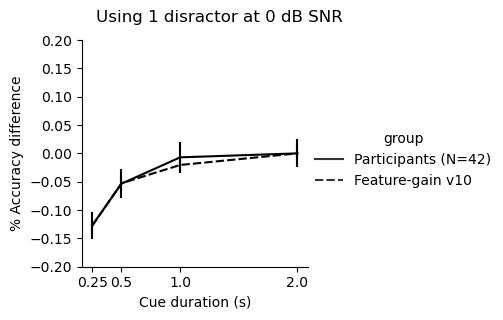

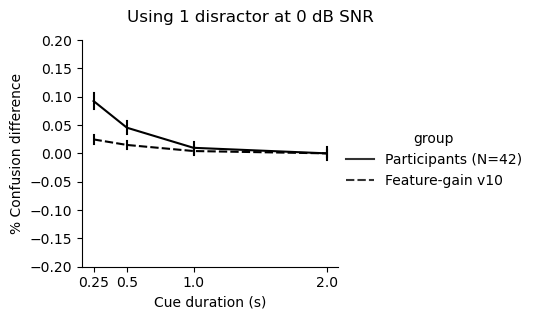

In [101]:
### new model vs humans 



group_order = [ f"Participants (N={part_summary_df.id_subject.nunique()})", 'Feature-gain v10 ']
to_plot = all_results[(all_results.cue_dur.isin([0.1, 0.25, 0.5,1,2])) & (all_results.group.isin(group_order))].copy()
# add markers to relplot
g = sns.relplot(data=to_plot, x='cue_dur', y='accuracy_delta', # hue='gender_cond',
                # col_wrap=3,
                # col='group', col_order=group_order,
                style='group',
                kind='line', marker='',
                color='k',
                height=3, aspect=1.25,
                err_style='bars', 
                errorbar=('se', 1),)

# set labels 
g.set_axis_labels("Cue duration (s)", "% Accuracy difference")
g.set_titles("{col_name}")

# add xtick labels
for ax in g.axes.flatten():
    ax.set_xticks(ticks=to_plot.cue_dur.unique())
    ax.set_xticklabels(to_plot.cue_dur.unique())

plt.ylim(-0.2,0.2)
plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)

# add markers to relplot
g = sns.relplot(data=to_plot, x='cue_dur', y='confusions_delta', # hue='gender_cond',
                # col='group', col_order=group_order,
                style='group',
                kind='line', marker='',
                color='k',
                height=3, aspect=1.25,
                err_style='bars', 
                errorbar=('se', 1),)


# set labels 
g.set_axis_labels("Cue duration (s)", "% Confusion difference")
g.set_titles("{col_name}")

# add xtick labels 

# add xtick labels
for ax in g.axes.flatten():
    ax.set_xticks(ticks=to_plot.cue_dur.unique())
    ax.set_xticklabels(to_plot.cue_dur.unique())

plt.ylim(-0.2,0.2)
plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)
# plt.tight_layout()

Text(0.5, 1.05, 'Using 1 disractor at 0 dB SNR')

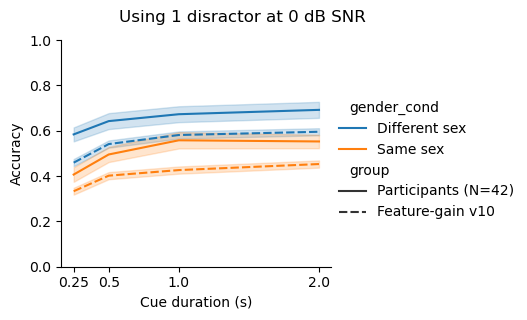

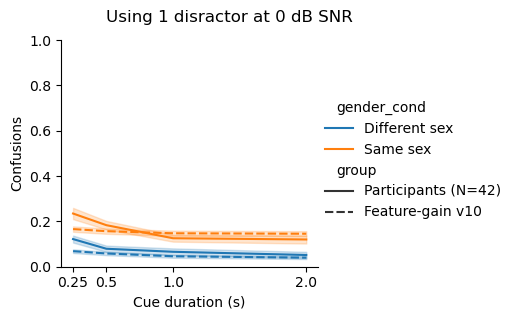

In [44]:
# part_summary_df
### new model vs humans 



group_order = [ f"Participants (N={part_summary_df.id_subject.nunique()})", 'Feature-gain v10 ']
to_plot = all_results[(all_results.cue_dur.isin([0.1,0.25, 0.5,1,2])) & (all_results.group.isin(group_order))].copy()
# add markers to relplot
g = sns.relplot(data=to_plot, x='cue_dur', y='adjusted_accuracy', hue='gender_cond',
                # col_wrap=3,
                # col='group', col_order=group_order,
                style='group',
                kind='line', marker='',
                color='k',
                height=3, aspect=1.25,
                # err_style='bars', 
                errorbar=('se', 1),)

# set labels 
g.set_axis_labels("Cue duration (s)", "Accuracy")
g.set_titles("{col_name}")

# add xtick labels
for ax in g.axes.flatten():
    ax.set_xticks(ticks=to_plot.cue_dur.unique())
    ax.set_xticklabels(to_plot.cue_dur.unique())

plt.ylim(0,1)
plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)

# add markers to relplot
g = sns.relplot(data=to_plot, x='cue_dur', y='adjusted_confusions', hue='gender_cond',
                # col='group', col_order=group_order,
                style='group',
                kind='line', marker='',
                color='k',
                height=3, aspect=1.25,
                # err_style='bars', 
                errorbar=('se', 1),)


# set labels 
g.set_axis_labels("Cue duration (s)", "Confusions")
g.set_titles("{col_name}")

# add xtick labels 

# add xtick labels
for ax in g.axes.flatten():
    ax.set_xticks(ticks=to_plot.cue_dur.unique())
    ax.set_xticklabels(to_plot.cue_dur.unique())

plt.ylim(0,1)
plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)
# plt.tight_layout()